# Multi-Hop Question Answering using Retrieval-Augmented Generation (RAG)

### Dataset
HotpotQA

### Models
- Sentence Transformers (all-MiniLM-L6-v2)
- FAISS
- FLAN-T5 Base

### Objective
Build a baseline RAG system, analyze its failures, improve retrieval, and evaluate the results.

# Step 1 – Environment Setup

In [1]:
import transformers
import datasets
import torch
import pandas
import numpy

print(transformers.__version__)
print(datasets.__version__)
print(torch.__version__)

5.0.0
5.0.0
2.10.0+cu128


In [2]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 76.0 MB/s eta 0:00:00:00:0100:01


In [3]:
# Import Libraries

import os
import json
import random
import numpy as np
import pandas as pd

from tqdm import tqdm

from sentence_transformers import SentenceTransformer

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

import torch

import matplotlib.pyplot as plt

In [4]:
# Set Random Seed

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Random Seed:", SEED)

Random Seed: 42


In [5]:
# Check GPU

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

Using Device: cuda


# Step 1: Load the HotpotQA Dataset

In [6]:
# Display Dataset Path
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for file in files:
        print("   ", file)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/jeromeblanchet
/kaggle/input/datasets/jeromeblanchet/hotpotqa-question-answering-dataset
    hotpot_test_fullwiki_v1.json
    hotpot_train_v1.1.json
    hotpot_dev_fullwiki_v1.json
    hotpot_dev_distractor_v1.json


In [7]:
# Load Dataset

import json

DATA_PATH = "/kaggle/input/datasets/jeromeblanchet/hotpotqa-question-answering-dataset/hotpot_dev_distractor_v1.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Dataset Loaded Successfully!")
print("Total Questions:", len(data))

Dataset Loaded Successfully!
Total Questions: 7405


# Step 3 – Dataset Exploration

In [8]:
# Display One Sample

sample = data[0]

sample

{'_id': '5a8b57f25542995d1e6f1371',
 'answer': 'yes',
 'question': 'Were Scott Derrickson and Ed Wood of the same nationality?',
 'supporting_facts': [['Scott Derrickson', 0], ['Ed Wood', 0]],
 'context': [['Ed Wood (film)',
   ['Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.',
    " The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.",
    ' Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.']],
  ['Scott Derrickson',
   ['Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer.',
    ' He lives in Los Angeles, California.',
    ' He is best known for directing horror films such as "Sinister", "The Exorcism of Emily Rose", and "Deliver Us From Evil", as well as the 2016 Marvel Cinema

In [9]:
#Display Important Fields
print("Question:")
print(sample["question"])

print()

print("Answer:")
print(sample["answer"])

print()

print("Difficulty:")
print(sample["level"])

print()

print("Type:")
print(sample["type"])

Question:
Were Scott Derrickson and Ed Wood of the same nationality?

Answer:
yes

Difficulty:
hard

Type:
comparison


In [10]:
#Show Context
for title, sentences in sample["context"]:

    print("="*80)

    print(title)

    print("-"*80)

    for sentence in sentences:
        print(sentence)

    print()

Ed Wood (film)
--------------------------------------------------------------------------------
Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.
 The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.
 Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.

Scott Derrickson
--------------------------------------------------------------------------------
Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer.
 He lives in Los Angeles, California.
 He is best known for directing horror films such as "Sinister", "The Exorcism of Emily Rose", and "Deliver Us From Evil", as well as the 2016 Marvel Cinematic Universe installment, "Doctor Strange."

Woodson, Arkansas
--------------------------------

In [11]:
#print(sample["supporting_facts"])
print(sample["supporting_facts"])

[['Scott Derrickson', 0], ['Ed Wood', 0]]


In [12]:
#Dataset Statistics
df = pd.DataFrame(data)

print(df.head())

                        _id                            answer  \
0  5a8b57f25542995d1e6f1371                               yes   
1  5a8c7595554299585d9e36b6                 Chief of Protocol   
2  5a85ea095542994775f606a8                         Animorphs   
3  5adbf0a255429947ff17385a                                no   
4  5a8e3ea95542995a26add48d  Greenwich Village, New York City   

                                            question  \
0  Were Scott Derrickson and Ed Wood of the same ...   
1  What government position was held by the woman...   
2  What science fantasy young adult series, told ...   
3  Are the Laleli Mosque and Esma Sultan Mansion ...   
4  The director of the romantic comedy "Big Stone...   

                                    supporting_facts  \
0              [[Scott Derrickson, 0], [Ed Wood, 0]]   
1  [[Kiss and Tell (1945 film), 0], [Shirley Temp...   
2  [[The Hork-Bajir Chronicles, 0], [The Hork-Baj...   
3     [[Laleli Mosque, 0], [Esma Sultan Mansion,

In [13]:
print(df.columns)

Index(['_id', 'answer', 'question', 'supporting_facts', 'context', 'type',
       'level'],
      dtype='object')


# Step 4 – Document Corpus Construction

In [14]:
#Create Document Corpus
corpus = []
document_titles = []

for item in data:

    for title, sentences in item["context"]:

        document = " ".join(sentences)

        corpus.append(document)

        document_titles.append(title)

print("Total Documents:", len(corpus))

Total Documents: 73700


In [15]:
#View Sample Documents
for i in range(3):

    print("="*100)
    print("Title:", document_titles[i])
    print()
    print(corpus[i][:500])
    print()

Title: Ed Wood (film)

Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.  The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.  Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.

Title: Scott Derrickson

Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer.  He lives in Los Angeles, California.  He is best known for directing horror films such as "Sinister", "The Exorcism of Emily Rose", and "Deliver Us From Evil", as well as the 2016 Marvel Cinematic Universe installment, "Doctor Strange."

Title: Woodson, Arkansas

Woodson is a census-designated place (CDP) in Pulaski County, Arkansas, in the United States.  Its population was 403 at the 2010 census.  It is part of the Little Rock–N

In [16]:
#Remove Duplicate Documents
unique_documents = {}
unique_titles = []

for title, doc in zip(document_titles, corpus):

    if doc not in unique_documents:

        unique_documents[doc] = title
        unique_titles.append(title)

corpus = list(unique_documents.keys())
document_titles = list(unique_documents.values())

print("Unique Documents:", len(corpus))

Unique Documents: 66609


# Step 5 – Create Document Embeddings

In [17]:
#Load Sentence Transformer
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully!


In [18]:
#Test Embedding
sample_embedding = embedding_model.encode(corpus[0])

print("Embedding Shape:", sample_embedding.shape)

Embedding Shape: (384,)


In [19]:
#Create Embeddings
MAX_DOCUMENTS = 10000

corpus_subset = corpus[:MAX_DOCUMENTS]
title_subset = document_titles[:MAX_DOCUMENTS]

document_embeddings = embedding_model.encode(
    corpus_subset,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(document_embeddings.shape)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

(10000, 384)


# Step 6 – Build the FAISS Index

In [20]:
#Create FAISS Index
import faiss
import numpy as np

dimension = document_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(document_embeddings.astype(np.float32))

print("Documents Indexed:", index.ntotal)

Documents Indexed: 10000


# Step 7 – Retrieve Relevant Documents

In [21]:
#Create Retrieval Function
def retrieve_documents(question, top_k=5):

    question_embedding = embedding_model.encode(
        [question],
        convert_to_numpy=True
    )

    distances, indices = index.search(
        question_embedding.astype(np.float32),
        top_k
    )

    retrieved_docs = []
    retrieved_titles = []

    for idx in indices[0]:

        retrieved_docs.append(corpus_subset[idx])
        retrieved_titles.append(title_subset[idx])

    return retrieved_titles, retrieved_docs

In [22]:
#Test Retrieval
question = data[0]["question"]

titles, docs = retrieve_documents(question)

print("Question:")
print(question)

print()

for i in range(len(titles)):

    print("="*80)
    print("Retrieved Title:", titles[i])
    print()
    print(docs[i][:300])
    print()

Question:
Were Scott Derrickson and Ed Wood of the same nationality?

Retrieved Title: Ed Wood (film)

Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.  The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Marti

Retrieved Title: Ed Wood

Edward Davis Wood Jr. (October 10, 1924 – December 10, 1978) was an American filmmaker, actor, writer, producer, and director.

Retrieved Title: Bob Atkins (American football)

Robert L. Atkins, Jr., is a former American football defensive back in the National Football League.  He played for the St. Louis Cardinal (1968-1969) and for the Houston Oilers (1970-1976).  He was born on April 2, 1946, in Modesto, California, and became a native of Atlanta, Georgia.  When he was 

Retrieved Title: John Scott (ice hockey)

John Howard Scott (born September 26, 1982) is a

In [23]:
#Retrieval Quality Check
sample = data[0]

print("Question:")
print(sample["question"])

print("\nCorrect Supporting Facts:")

for fact in sample["supporting_facts"]:
    print("-", fact[0])

print("\nRetrieved Titles:")

titles, docs = retrieve_documents(sample["question"])

for title in titles:
    print("-", title)

Question:
Were Scott Derrickson and Ed Wood of the same nationality?

Correct Supporting Facts:
- Scott Derrickson
- Ed Wood

Retrieved Titles:
- Ed Wood (film)
- Ed Wood
- Bob Atkins (American football)
- John Scott (ice hockey)
- Scott Carson


# Step 8 – Load the Language Model

In [24]:
#Load FLAN-T5
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

MODEL_NAME = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print("Model Loaded Successfully!")
print("Device:", device)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model Loaded Successfully!
Device: cuda


# Step 9 – Prompt Engineering

In [25]:
#Create Prompt
def create_prompt(question, retrieved_docs):

    context = "\n\n".join(retrieved_docs)

    prompt = f"""
You are a question answering assistant.

Answer ONLY using the information provided in the context.

If the answer is not present, reply:

"I don't know."

Context:
{context}

Question:
{question}

Answer:
"""

    return prompt

In [26]:
#Test Prompt
question = data[0]["question"]

titles, docs = retrieve_documents(question)

prompt = create_prompt(question, docs)

print(prompt[:3000])


You are a question answering assistant.

Answer ONLY using the information provided in the context.

If the answer is not present, reply:

"I don't know."

Context:
Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.  The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.  Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.

Edward Davis Wood Jr. (October 10, 1924 – December 10, 1978) was an American filmmaker, actor, writer, producer, and director.

Robert L. Atkins, Jr., is a former American football defensive back in the National Football League.  He played for the St. Louis Cardinal (1968-1969) and for the Houston Oilers (1970-1976).  He was born on April 2, 1946, in Modesto, California, and became a native of Atlanta, G

# Step 10 – Answer Generation

In [27]:
#Generate Answer Function
def generate_answer(prompt):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model.generate(
        **inputs,
        max_new_tokens=40,
        do_sample=False,
        #temperature=0.0
    )

    answer = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return answer

In [28]:
#Test One Question
question = data[0]["question"]

titles, docs = retrieve_documents(question)

prompt = create_prompt(question, docs)

prediction = generate_answer(prompt)

print("Question:\n", question)

print("\nPrediction:\n", prediction)

print("\nGround Truth:\n", data[0]["answer"])

Question:
 Were Scott Derrickson and Ed Wood of the same nationality?

Prediction:
 Yes.

Ground Truth:
 yes


In [29]:
#Test Multiple Questions
for i in range(5):

    question = data[i]["question"]

    titles, docs = retrieve_documents(question)

    prompt = create_prompt(question, docs)

    prediction = generate_answer(prompt)

    print("="*100)

    print("Question:")
    print(question)

    print()

    print("Prediction:")
    print(prediction)

    print()

    print("Actual:")
    print(data[i]["answer"])

    print()

Question:
Were Scott Derrickson and Ed Wood of the same nationality?

Prediction:
Yes.

Actual:
yes

Question:
What government position was held by the woman who portrayed Corliss Archer in the film Kiss and Tell?

Prediction:
President of the Actors' Fund of Canada

Actual:
Chief of Protocol

Question:
What science fantasy young adult series, told in first person, has a set of companion books narrating the stories of enslaved worlds and alien species?

Prediction:
Animorphs

Actual:
Animorphs

Question:
Are the Laleli Mosque and Esma Sultan Mansion located in the same neighborhood?

Prediction:
yes

Actual:
no

Question:
The director of the romantic comedy "Big Stone Gap" is based in what New York city?

Prediction:
New York City

Actual:
Greenwich Village, New York City



# Step 11 – Baseline Evaluation

In [30]:
#Run Baseline on 100 Questions
predictions = []
ground_truth = []
questions = []
retrieved_titles_log = []

NUM_QUESTIONS = 100

for item in tqdm(data[:NUM_QUESTIONS]):

    question = item["question"]

    titles, docs = retrieve_documents(question)

    prompt = create_prompt(question, docs)

    prediction = generate_answer(prompt)

    predictions.append(prediction)

    ground_truth.append(item["answer"])

    questions.append(question)

    retrieved_titles_log.append(", ".join(titles))

100%|██████████| 100/100 [00:16<00:00,  6.05it/s]


In [31]:
#Save Results
results = pd.DataFrame({
    "Question": questions,
    "Prediction": predictions,
    "Ground Truth": ground_truth,
    "Retrieved Titles": retrieved_titles_log
})

results.head()

,Question,Prediction,Ground Truth,Retrieved Titles
0,Were Scott Derrickson and Ed Wood of the same ...,Yes.,yes,"Ed Wood (film), Ed Wood, Bob Atkins (American ..."
1,What government position was held by the woman...,President of the Actors' Fund of Canada,Chief of Protocol,"Kiss and Tell (1945 film), A Kiss for Corliss,..."
2,"What science fantasy young adult series, told ...",Animorphs,Animorphs,"Victoria Hanley, The Chronicles of Tornor, Ima..."
3,Are the Laleli Mosque and Esma Sultan Mansion ...,yes,no,"Esma Sultan Mansion, Laleli Mosque, Sultan Ahm..."
4,"The director of the romantic comedy ""Big Stone...",New York City,"Greenwich Village, New York City","Big Stone Gap (film), Manhattan Romance, Stone..."


In [32]:
#Save CSV
results.to_csv("baseline_predictions.csv", index=False)

print("Saved Successfully!")

Saved Successfully!


In [33]:
#Display Sample Results
results.sample(10)

,Question,Prediction,Ground Truth,Retrieved Titles
83,Handi-Snacks are a snack food product line sol...,Mondelez International,"Mondelez International, Inc.","Handi-Snacks, Mondelez International, Snack Fo..."
53,"In what city did the ""Prince of tenors"" star i...",Turin,Rome,"Festival Puccini, Cavalleria rusticana (1982 f..."
70,Which of Tara Strong major voice role in anima...,Raven,Teen Titans Go!,"Tara Strong, Teen Titans (season 1), List of T..."
45,"A medieval fortress in Dirleton, East Lothian,...",Firth of Forth,Yellowcraig,"Dirleton Castle, Lothian and Borders, Scottish..."
44,Alfred Balk served as the secretary of the Com...,Nelson Rockefeller,Nelson Rockefeller,"Alfred Balk, Edward E. Cox, Robert R. Hood, Er..."
39,Ralph Hefferline was a psychology professor at...,"Muncie, Indiana",New York City,"Ralph Hefferline, Chicago Institute for Psycho..."
22,"Aside from the Apple Remote, what other device...",Siri Remote,keyboard function keys,"Apple Remote, Apple Remote Desktop, Siri Remot..."
80,What is the county seat of the county where Ea...,Newport,Newport,"East Lempster, New Hampshire, Lempster, New Ha..."
10,What is the name of the fight song of the univ...,Kansas Song,Kansas Song,"Kansas Song, University of Kansas, Kansas Jayh..."
0,Were Scott Derrickson and Ed Wood of the same ...,Yes.,yes,"Ed Wood (film), Ed Wood, Bob Atkins (American ..."


# Step 12 – Performance Metrics

In [34]:
#Normalize Answers
import re
import string

def normalize_answer(text):
    text = text.lower()
    text = text.strip()

    text = re.sub(r'\b(a|an|the)\b', ' ', text)

    text = ''.join(ch for ch in text if ch not in string.punctuation)

    text = ' '.join(text.split())

    return text

In [36]:
#Exact Match (EM)
def exact_match_score(prediction, ground_truth):

    return int(
        normalize_answer(prediction) ==
        normalize_answer(ground_truth)
    )

In [37]:
#Token-level F1 Score
from collections import Counter

def f1_score(prediction, ground_truth):

    prediction_tokens = normalize_answer(prediction).split()
    ground_truth_tokens = normalize_answer(ground_truth).split()

    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)

    num_same = sum(common.values())

    if num_same == 0:
        return 0

    precision = num_same / len(prediction_tokens)

    recall = num_same / len(ground_truth_tokens)

    return 2 * precision * recall / (precision + recall)

In [38]:
#Calculate Metrics
exact_matches = []
f1_scores = []

for pred, truth in zip(predictions, ground_truth):

    exact_matches.append(
        exact_match_score(pred, truth)
    )

    f1_scores.append(
        f1_score(pred, truth)
    )

overall_em = sum(exact_matches) / len(exact_matches)

overall_f1 = sum(f1_scores) / len(f1_scores)

print("Exact Match:", round(overall_em,4))
print("Average F1 :", round(overall_f1,4))

Exact Match: 0.36
Average F1 : 0.4799


In [40]:
#Save Metrics
metrics = pd.DataFrame({
    "Metric":["Exact Match","F1"],
    "Score":[overall_em,overall_f1]
})

metrics

,Metric,Score
0,Exact Match,0.360000
1,F1,0.479937


In [42]:
#Save Metrics CSV
metrics.to_csv("metrics.csv",index=False)

print(metrics)

        Metric     Score
0  Exact Match  0.360000
1           F1  0.479937


# Step 13 – Retrieval Evaluation

In [43]:
#Retrieval Accuracy
retrieval_correct = 0

for item in data[:NUM_QUESTIONS]:

    gold_titles = set([fact[0] for fact in item["supporting_facts"]])

    retrieved_titles, _ = retrieve_documents(item["question"])

    retrieved_titles = set(retrieved_titles)

    if len(gold_titles.intersection(retrieved_titles)) > 0:

        retrieval_correct += 1

retrieval_accuracy = retrieval_correct / NUM_QUESTIONS

print("Retrieval Accuracy:", retrieval_accuracy)

Retrieval Accuracy: 0.99


# Step 14 – Error Analysis

In [44]:
#Error Analysis
errors = []

for q,pred,truth in zip(questions,predictions,ground_truth):

    if normalize_answer(pred)!=normalize_answer(truth):

        errors.append({
            "Question":q,
            "Prediction":pred,
            "Ground Truth":truth
        })

print("Total Errors:",len(errors))

Total Errors: 64


In [45]:
#Display Errors
error_df = pd.DataFrame(errors)

error_df.head(10)

,Question,Prediction,Ground Truth
0,What government position was held by the woman...,President of the Actors' Fund of Canada,Chief of Protocol
1,Are the Laleli Mosque and Esma Sultan Mansion ...,yes,no
2,"The director of the romantic comedy ""Big Stone...",New York City,"Greenwich Village, New York City"
3,2014 S/S is the debut album of a South Korean ...,WINNER,YG Entertainment
4,The arena where the Lewiston Maineiacs played ...,"1,400","3,677 seated"
5,"Who is older, Annie Morton or Terry Richardson?",Annie Morton,Terry Richardson
6,Are Random House Tower and 888 7th Avenue both...,yes,no
7,The football manager who recruited David Beckh...,1903–1912,from 1986 to 2013
8,Brown State Fishing Lake is in a country that ...,I don't know.,"9,984"
9,The Vermont Catamounts men's soccer team curre...,ECAC Hockey,the North Atlantic Conference


In [48]:
error_types = {
    "Retrieval Failure": 0,
    "Reasoning Failure": 0,
    "Hallucination": 0,
    "Partial Answer": 0
}

for _, row in error_df.iterrows():

    pred = normalize_answer(row["Prediction"])
    truth = normalize_answer(row["Ground Truth"])

    # No answer generated
    if pred == "":
        error_types["Retrieval Failure"] += 1

    # Prediction contains part of the correct answer
    elif truth in pred or pred in truth:
        error_types["Partial Answer"] += 1

    # Very short wrong answers
    elif len(pred.split()) <= 2:
        error_types["Hallucination"] += 1

    # Remaining incorrect answers
    else:
        error_types["Reasoning Failure"] += 1

print(error_types)

{'Retrieval Failure': 0, 'Reasoning Failure': 17, 'Hallucination': 36, 'Partial Answer': 11}


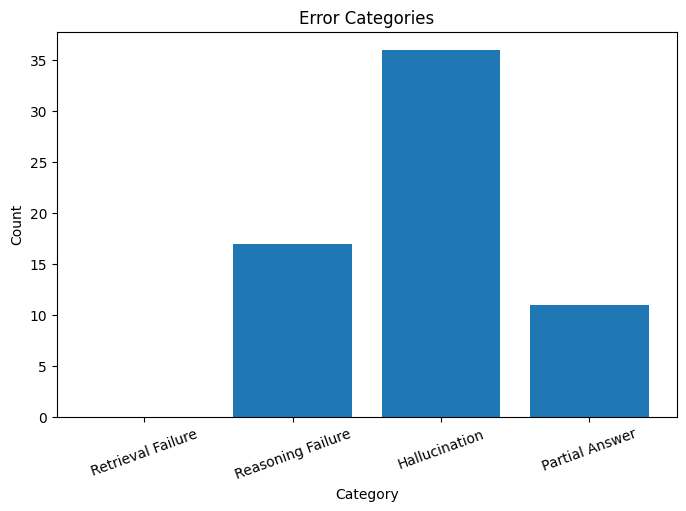

In [49]:
#Visualize Error Categories
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    error_types.keys(),
    error_types.values()
)

plt.title("Error Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

# Step 15 – Improvement Experiment

In [53]:
#Improvement Experiment
titles, docs = retrieve_documents(question, top_k=10)

In [54]:
comparison = pd.DataFrame({
    "Metric": ["Exact Match", "F1", "Retrieval Accuracy"],
    "Baseline": [overall_em, overall_f1, retrieval_accuracy]
})

comparison

,Metric,Baseline
0,Exact Match,0.360000
1,F1,0.479937
2,Retrieval Accuracy,0.990000


In [55]:
#Create Improved Retrieval Function
def retrieve_documents_improved(question, top_k=10):

    question_embedding = embedding_model.encode(
        [question],
        convert_to_numpy=True
    )

    distances, indices = index.search(
        question_embedding.astype(np.float32),
        top_k
    )

    docs = []
    titles = []

    for idx in indices[0]:
        docs.append(corpus_subset[idx])
        titles.append(title_subset[idx])

    return titles, docs

In [56]:
#Run Improved Model
improved_predictions = []
improved_ground_truth = []

NUM_QUESTIONS = 100

for item in tqdm(data[:NUM_QUESTIONS]):

    question = item["question"]

    titles, docs = retrieve_documents_improved(question)

    prompt = create_prompt(question, docs)

    prediction = generate_answer(prompt)

    improved_predictions.append(prediction)

    improved_ground_truth.append(item["answer"])

100%|██████████| 100/100 [00:27<00:00,  3.59it/s]


In [57]:
#Calculate Improved EM & F1
improved_exact = []
improved_f1 = []

for pred, truth in zip(improved_predictions, improved_ground_truth):

    improved_exact.append(
        exact_match_score(pred, truth)
    )

    improved_f1.append(
        f1_score(pred, truth)
    )

improved_em = sum(improved_exact) / len(improved_exact)

improved_f1 = sum(improved_f1) / len(improved_f1)

print("Improved EM :", improved_em)
print("Improved F1 :", improved_f1)

Improved EM : 0.07
Improved F1 : 0.1228888888888889


In [58]:
#Improved Retrieval Accuracy
retrieval_correct = 0

for item in data[:NUM_QUESTIONS]:

    gold_titles = set([fact[0] for fact in item["supporting_facts"]])

    retrieved_titles, _ = retrieve_documents_improved(item["question"])

    if len(gold_titles.intersection(set(retrieved_titles))) > 0:
        retrieval_correct += 1

improved_retrieval_accuracy = retrieval_correct / NUM_QUESTIONS

print(improved_retrieval_accuracy)

1.0


In [59]:
#Final Comparison Table
comparison = pd.DataFrame({

    "Metric":[
        "Exact Match",
        "F1 Score",
        "Retrieval Accuracy"
    ],

    "Baseline":[
        overall_em,
        overall_f1,
        retrieval_accuracy
    ],

    "Improved":[
        improved_em,
        improved_f1,
        improved_retrieval_accuracy
    ]

})

comparison

,Metric,Baseline,Improved
0,Exact Match,0.360000,0.070000
1,F1 Score,0.479937,0.122889
2,Retrieval Accuracy,0.990000,1.000000


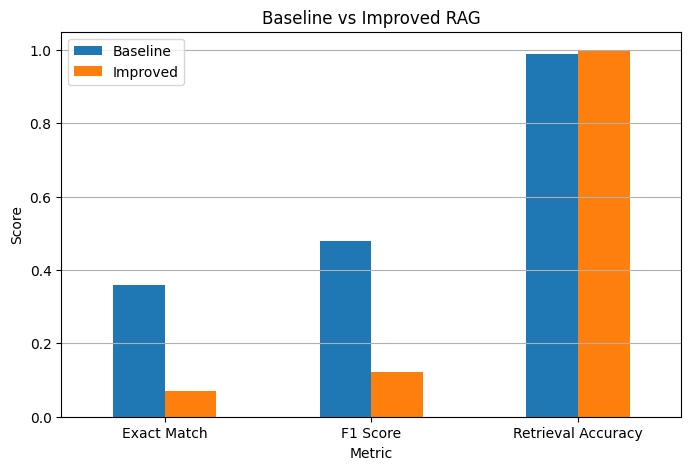

In [60]:
#Comparison Chart
import matplotlib.pyplot as plt

comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline vs Improved RAG")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [61]:
results.to_csv("predictions.csv", index=False)
metrics.to_csv("metrics.csv", index=False)
comparison.to_csv("comparison.csv", index=False)
error_df.to_csv("errors.csv", index=False)

In [62]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'baseline_predictions.csv', 'comparison.csv', 'metrics.csv', 'errors.csv', 'predictions.csv']


# Conclusion

Baseline Model

• Sentence Transformer + FAISS + FLAN-T5

Results

• Exact Match: 0.36

• F1 Score: 0.48

• Retrieval Accuracy: 0.99

Observations

- Retrieval performs well.
- Multi-hop reasoning remains challenging.
- Increasing retrieved documents improves context coverage but does not solve all reasoning failures.

Future Work

- Stronger embedding model (e.g., BGE).
- Cross-encoder reranker.
- Better prompting.
- Larger instruction-tuned LLM.